In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import random
import re
import unicodedata
from collections import Counter
import matplotlib.pyplot as plt

In [3]:
# Data Loading + Preprocessing

def unicode_to_ascii(s):
    return ''.join(c for c in unicodedata.normalize('NFD', s)
                   if unicodedata.category(c) != 'Mn')

def clean_en(text):
    text = unicode_to_ascii(text.lower().strip())
    text = re.sub(r"[^a-zA-Z.!?]+", " ", text)
    return text.strip()

def clean_ru(text):
    text = text.lower().strip()
    text = re.sub(r"[^а-яёА-ЯЁ.!?]+", " ", text)
    return text.strip()

def load_data(filepath, max_len=15, num_samples=30000):
    pairs = []
    with open(filepath, "r", encoding="utf-8") as f:
        for line in f:
            parts = line.strip().split("\t")
            if len(parts) < 2:
                continue
            en = clean_en(parts[0])
            ru = clean_ru(parts[1])
            if len(en.split()) <= max_len and len(ru.split()) <= max_len:
                pairs.append((en, ru))
            if len(pairs) >= num_samples:
                break

    random.shuffle(pairs)
    return pairs

pairs = load_data("rus.txt")
print(f"Total pairs: {len(pairs)}")
print("Examples:")
for en, ru in pairs[:5]:
    print(f"  EN: {en}")
    print(f"  RU: {ru}")
    print()

Total pairs: 30000
Examples:
  EN: i followed you.
  RU: я ехал за вами.

  EN: he was very old.
  RU: он был очень стар.

  EN: let s have tea.
  RU: давайте чаю выпьем.

  EN: don t come again.
  RU: больше не приходите.

  EN: it smells good!
  RU: вкусно пахнет!



In [4]:
# Vocabulary + Dataset + DataLoader

class Vocabulary:
    def __init__(self, name):
        self.name = name
        self.word2idx = {"<pad>": 0, "<sos>": 1, "<eos>": 2, "<unk>": 3}
        self.idx2word = {0: "<pad>", 1: "<sos>", 2: "<eos>", 3: "<unk>"}
        self.n_words  = 4

    def add_sentence(self, sentence):
        for word in sentence.split():
            self.add_word(word)

    def add_word(self, word):
        if word not in self.word2idx:
            self.word2idx[word] = self.n_words
            self.idx2word[self.n_words] = word
            self.n_words += 1

en_vocab = Vocabulary("english")
ru_vocab = Vocabulary("russian")

split_idx  = int(len(pairs) * 0.9)
train_pairs = pairs[:split_idx]
val_pairs = pairs[split_idx:]

for en, ru in train_pairs:
    en_vocab.add_sentence(en)
    ru_vocab.add_sentence(ru)

print(f"English vocab size: {en_vocab.n_words}")
print(f"Russian vocab size: {ru_vocab.n_words}")
print(f"Train pairs: {len(train_pairs)} | Val pairs: {len(val_pairs)}")


class TranslationDataset(Dataset):
    def __init__(self, pairs, en_vocab, ru_vocab):
        self.pairs = pairs
        self.en_vocab = en_vocab
        self.ru_vocab = ru_vocab

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        en, ru = self.pairs[idx]
        en_ids = [self.en_vocab.word2idx.get(w, 3) for w in en.split()]
        ru_ids = [1] + [self.ru_vocab.word2idx.get(w, 3) for w in ru.split()] + [2]
        return torch.tensor(en_ids, dtype=torch.long), torch.tensor(ru_ids, dtype=torch.long)


def collate_fn(batch):
    en_batch, ru_batch = zip(*batch)
    en_padded = nn.utils.rnn.pad_sequence(en_batch, batch_first=False, padding_value=0)
    ru_padded = nn.utils.rnn.pad_sequence(ru_batch, batch_first=False, padding_value=0)
    return en_padded, ru_padded


train_dataset = TranslationDataset(train_pairs, en_vocab, ru_vocab)
val_dataset = TranslationDataset(val_pairs,   en_vocab, ru_vocab)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True,  collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, collate_fn=collate_fn)

en_batch, ru_batch = next(iter(train_loader))
print(f"\nEN batch shape: {en_batch.shape}")
print(f"RU batch shape: {ru_batch.shape}")

English vocab size: 4937
Russian vocab size: 12408
Train pairs: 27000 | Val pairs: 3000

EN batch shape: torch.Size([5, 64])
RU batch shape: torch.Size([8, 64])


In [5]:
# Encoder + Decoder + Seq2Seq

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

EMBED_DIM = 256
HIDDEN_DIM = 1024
DROPOUT = 0.3


class Encoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, dropout):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=False)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        embedded = self.dropout(self.embedding(x))
        _, (hidden, cell) = self.lstm(embedded)
        return hidden, cell


class Decoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, dropout):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=False)
        self.fc = nn.Linear(hidden_dim, vocab_size)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, hidden, cell):
        x = x.unsqueeze(0)
        embedded = self.dropout(self.embedding(x))
        output, (hidden, cell) = self.lstm(embedded, (hidden, cell))
        prediction = self.fc(output.squeeze(0))
        return prediction, hidden, cell


class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, src, trg, teacher_forcing_ratio=0.5):
        batch_size = src.shape[1]
        trg_len = trg.shape[0]
        trg_vocab = self.decoder.fc.out_features

        outputs = torch.zeros(trg_len, batch_size, trg_vocab).to(self.device)
        hidden, cell = self.encoder(src)

        input_token = trg[0]

        for t in range(1, trg_len):
            output, hidden, cell = self.decoder(input_token, hidden, cell)
            outputs[t] = output
            teacher_force = random.random() < teacher_forcing_ratio
            input_token = trg[t] if teacher_force else output.argmax(1)

        return outputs


encoder = Encoder(en_vocab.n_words, EMBED_DIM, HIDDEN_DIM, DROPOUT).to(device)
decoder = Decoder(ru_vocab.n_words, EMBED_DIM, HIDDEN_DIM, DROPOUT).to(device)
model = Seq2Seq(encoder, decoder, device).to(device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(model)

Device: cuda
Total parameters: 27,660,664
Seq2Seq(
  (encoder): Encoder(
    (embedding): Embedding(4937, 256, padding_idx=0)
    (lstm): LSTM(256, 1024)
    (dropout): Dropout(p=0.3, inplace=False)
  )
  (decoder): Decoder(
    (embedding): Embedding(12408, 256, padding_idx=0)
    (lstm): LSTM(256, 1024)
    (fc): Linear(in_features=1024, out_features=12408, bias=True)
    (dropout): Dropout(p=0.3, inplace=False)
  )
)


In [6]:
# Training + Evaluation Functions

optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss(ignore_index=0)


def train_epoch(model, loader, optimizer, criterion, clip=1.0):
    model.train()
    epoch_loss = 0

    for src, trg in loader:
        src, trg = src.to(device), trg.to(device)

        optimizer.zero_grad()
        output = model(src, trg, teacher_forcing_ratio=0.5)

        output = output[1:].reshape(-1, output.shape[-1])
        trg = trg[1:].reshape(-1)

        loss = criterion(output, trg)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
        optimizer.step()

        epoch_loss += loss.item()

    return epoch_loss / len(loader)


def evaluate(model, loader, criterion):
    model.eval()
    epoch_loss = 0

    with torch.no_grad():
        for src, trg in loader:
            src, trg = src.to(device), trg.to(device)
            output = model(src, trg, teacher_forcing_ratio=0.0)

            output = output[1:].reshape(-1, output.shape[-1])
            trg = trg[1:].reshape(-1)

            loss = criterion(output, trg)
            epoch_loss += loss.item()

    return epoch_loss / len(loader)

Epoch  1/20 | Train Loss: 4.5345 | Val Loss: 3.7476 | Train PPL:   93.18 | Val PPL:   42.42
Epoch  2/20 | Train Loss: 3.0355 | Val Loss: 3.1690 | Train PPL:   20.81 | Val PPL:   23.78
Epoch  3/20 | Train Loss: 2.0944 | Val Loss: 2.8731 | Train PPL:    8.12 | Val PPL:   17.69
Epoch  4/20 | Train Loss: 1.4899 | Val Loss: 2.7859 | Train PPL:    4.44 | Val PPL:   16.21
Epoch  5/20 | Train Loss: 1.1496 | Val Loss: 2.8005 | Train PPL:    3.16 | Val PPL:   16.45
Epoch  6/20 | Train Loss: 0.9644 | Val Loss: 2.8491 | Train PPL:    2.62 | Val PPL:   17.27
Epoch  7/20 | Train Loss: 0.8666 | Val Loss: 2.8766 | Train PPL:    2.38 | Val PPL:   17.75
Epoch  8/20 | Train Loss: 0.7948 | Val Loss: 2.9197 | Train PPL:    2.21 | Val PPL:   18.53
Epoch  9/20 | Train Loss: 0.7559 | Val Loss: 2.9655 | Train PPL:    2.13 | Val PPL:   19.40
Epoch 10/20 | Train Loss: 0.7233 | Val Loss: 2.9510 | Train PPL:    2.06 | Val PPL:   19.12
Epoch 11/20 | Train Loss: 0.7045 | Val Loss: 2.9671 | Train PPL:    2.02 | Val P

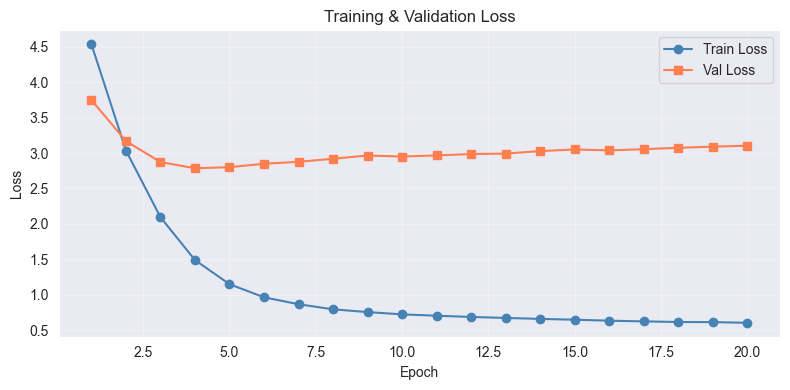

In [8]:
# Training Loop

NUM_EPOCHS = 20
best_val_loss = float("inf")
train_losses = []
val_losses = []

for epoch in range(NUM_EPOCHS):
    train_loss = train_epoch(model, train_loader, optimizer, criterion)
    val_loss = evaluate(model, val_loader, criterion)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "best_model.pt")

    print(f"Epoch {epoch+1:2d}/{NUM_EPOCHS} | "
          f"Train Loss: {train_loss:.4f} | "
          f"Val Loss: {val_loss:.4f} | "
          f"Train PPL: {np.exp(train_loss):7.2f} | "
          f"Val PPL: {np.exp(val_loss):7.2f}")

print(f"\nBest Val Loss: {best_val_loss:.4f}")

plt.figure(figsize=(8, 4))
plt.plot(range(1, NUM_EPOCHS+1), train_losses, marker="o", label="Train Loss", color="steelblue")
plt.plot(range(1, NUM_EPOCHS+1), val_losses,   marker="s", label="Val Loss",   color="coral")
plt.title("Training & Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [9]:
# Translation Function + Examples

model.load_state_dict(torch.load("best_model.pt"))
model.eval()

def translate(sentence, max_len=50):
    if isinstance(sentence, str):
        sentence = clean_en(sentence)
        tokens = [en_vocab.word2idx.get(w, 3) for w in sentence.split()]
        src = torch.tensor(tokens, dtype=torch.long).unsqueeze(1).to(device)
    else:
        src = sentence

    with torch.no_grad():
        hidden, cell = model.encoder(src)

    input_token = torch.tensor([ru_vocab.word2idx["<sos>"]], dtype=torch.long).to(device)
    translated = []

    with torch.no_grad():
        for _ in range(max_len):
            output, hidden, cell = model.decoder(input_token, hidden, cell)
            top_token = output.argmax(1)

            word = ru_vocab.idx2word[top_token.item()]
            if word == "<eos>":
                break
            translated.append(word)
            input_token = top_token

    return " ".join(translated)


print("=" * 55)
print("TRANSLATION EXAMPLES")
print("=" * 55)

test_sentences = [
    "i love you",
    "he is very old",
    "she is beautiful",
    "we are going home",
    "i don t know",
    "let s go",
    "how are you",
    "i am happy",
    "the cat is here",
    "good morning",
]

for en in test_sentences:
    ru = translate(en)
    print(f"  EN: {en}")
    print(f"  RU: {ru}")
    print()

print("=" * 55)
print("VALIDATION SET EXAMPLES (Ground Truth vs Predicted)")
print("=" * 55)

for en, ru_true in val_pairs[:8]:
    ru_pred = translate(en)
    print(f"  EN:   {en}")
    print(f"  TRUE: {ru_true}")
    print(f"  PRED: {ru_pred}")
    print()

TRANSLATION EXAMPLES
  EN: i love you
  RU: я люблю тебя обоих.

  EN: he is very old
  RU: он очень очень

  EN: she is beautiful
  RU: она невысокая.

  EN: we are going home
  RU: мы мы

  EN: i don t know
  RU: я не знаю

  EN: let s go
  RU: давай поедем

  EN: how are you
  RU: как вы дела?

  EN: i am happy
  RU: я меня всё в порядке.

  EN: the cat is here
  RU: кошка кот

  EN: good morning
  RU: удачи

VALIDATION SET EXAMPLES (Ground Truth vs Predicted)
  EN:   cats like boxes.
  TRUE: кошкам нравятся коробки.
  PRED: кошки любят коробки.

  EN:   i m really rich.
  TRUE: я очень богат.
  PRED: я очень богат.

  EN:   what ve you got?
  TRUE: что у тебя?
  PRED: что у вас?

  EN:   hi. how are you?
  TRUE: привет как дела?
  PRED: привет! как дела?

  EN:   tom was first.
  TRUE: том был первым.
  PRED: том был первым.

  EN:   is that so bad?
  TRUE: это так плохо?
  PRED: это так плохо?

  EN:   i said get back!
  TRUE: я сказала вернитесь!
  PRED: я сказал вернись!

  EN: 